Note: you may need to restart the kernel to use updated packages.


'DOSKEY'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


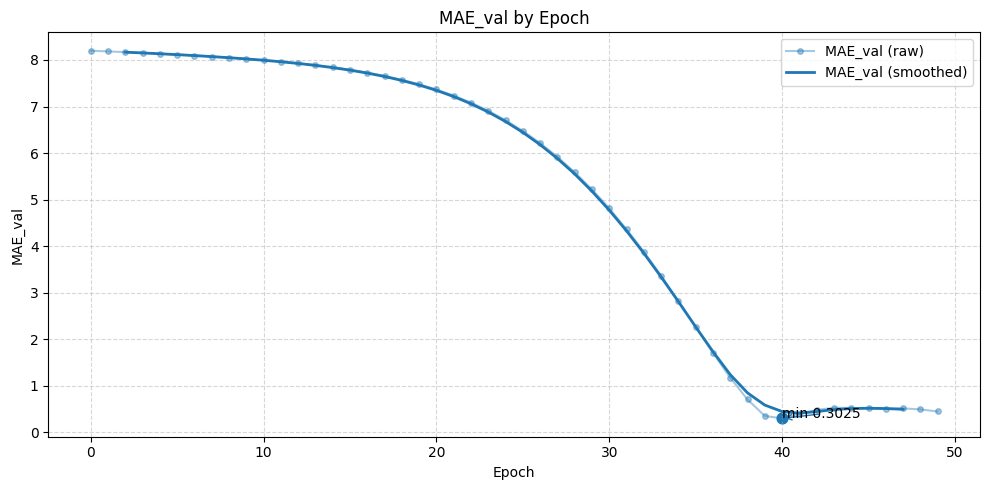

Note: you may need to restart the kernel to use updated packages.


'DOSKEY'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


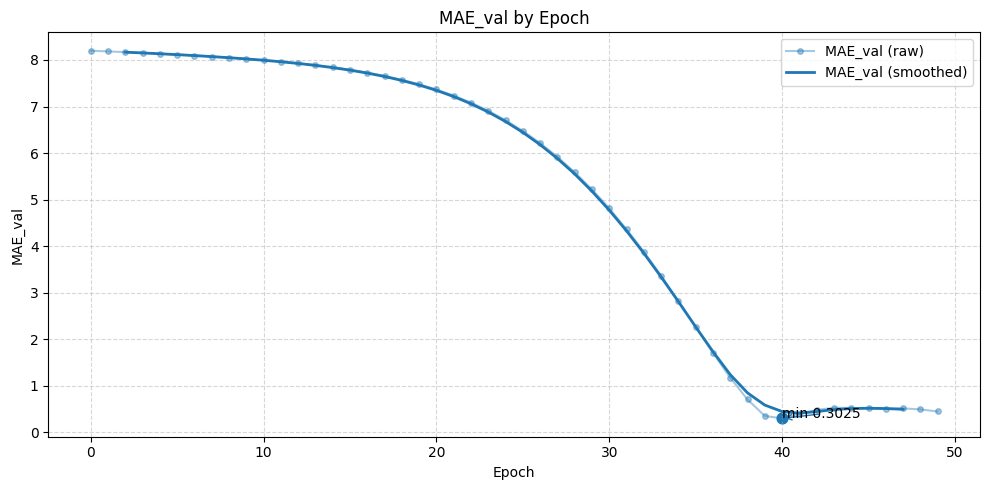

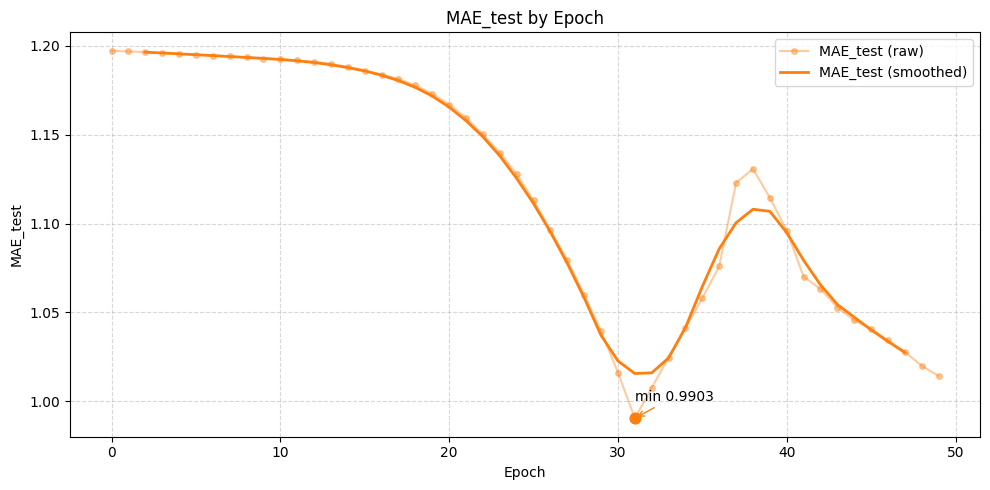

Parsed 50 epochs. Saved: C:\QuantumDeepField_molecule\output\MAE_val_plot.png, C:\QuantumDeepField_molecule\output\MAE_test_plot.png


In [13]:
%pip install matplotlib
import re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 파일 경로 지정 (필요하면 경로를 변경하세요)
data_path = Path('C:/QuantumDeepField_molecule/output/resulthomo.txt')
if not data_path.exists():
    raise FileNotFoundError(f'{data_path} not found. Check the path and file name.')

lines = data_path.read_text(encoding='utf-8').splitlines()

# 각 줄에서 마지막 두 수치(순서: ... MAE_val MAE_test)를 추출합니다.
mae_val = []
mae_test = []
for i, line in enumerate(lines):
    nums = re.findall(r'[-+]?\d*\.\d+|\d+', line)
    if len(nums) < 2:
        # 데이터가 적으면 스킵
        continue
    # 마지막 두 값이 MAE_val, MAE_test 라고 가정
    val = float(nums[-2])
    test = float(nums[-1])
    mae_val.append(val)
    mae_test.append(test)

epochs = np.arange(len(mae_val))

if len(mae_val) == 0:
    raise ValueError('파일에서 MAE_val/MAE_test 값을 찾을 수 없습니다. 로그 포맷을 확인하세요.')

# 스무딩 함수 (이동평균)
def smooth(y, window=5):
    y = np.array(y)
    if window <= 1 or len(y) < window:
        return y
    return np.convolve(y, np.ones(window)/window, mode='valid')

# 출력 폴더 준비
out_dir = Path('C:/QuantumDeepField_molecule/output')
out_dir.mkdir(parents=True, exist_ok=True)

# 1) MAE_val 그리기
plt.figure(figsize=(10,5))
plt.plot(epochs, mae_val, label='MAE_val (raw)', color='C0', alpha=0.4, marker='o', markersize=4)
mv = smooth(mae_val, window=5)
if len(mv) > 0:
    plt.plot(np.arange(len(mv)) + (5-1)/2, mv, label='MAE_val (smoothed)', color='C0', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MAE_val')
plt.title('MAE_val by Epoch')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
# annotate min
min_val = np.min(mae_val)
min_epoch = int(np.argmin(mae_val))
plt.scatter([min_epoch], [min_val], color='C0', s=60)
plt.annotate(f'min {min_val:.4f}', xy=(min_epoch, min_val), xytext=(min_epoch, min_val+0.01),
             arrowprops=dict(arrowstyle='->', color='C0'))
out_file_val = out_dir / 'MAE_val_plot.png'
plt.tight_layout()
plt.savefig(out_file_val, dpi=150)
plt.show()

# 2) MAE_test 그리기
plt.figure(figsize=(10,5))
plt.plot(epochs, mae_test, label='MAE_test (raw)', color='C1', alpha=0.4, marker='o', markersize=4)
mt = smooth(mae_test, window=5)
if len(mt) > 0:
    plt.plot(np.arange(len(mt)) + (5-1)/2, mt, label='MAE_test (smoothed)', color='C1', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MAE_test')
plt.title('MAE_test by Epoch')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
min_t = np.min(mae_test)
min_t_epoch = int(np.argmin(mae_test))
plt.scatter([min_t_epoch], [min_t], color='C1', s=60)
plt.annotate(f'min {min_t:.4f}', xy=(min_t_epoch, min_t), xytext=(min_t_epoch, min_t+0.01),
             arrowprops=dict(arrowstyle='->', color='C1'))
out_file_test = out_dir / 'MAE_test_plot.png'
plt.tight_layout()
plt.savefig(out_file_test, dpi=150)
plt.show()

# 요약 출력: 샘플 값 몇 개와 저장된 파일 경로
print(f'Parsed {len(mae_val)} epochs. Saved: {out_file_val}, {out_file_test}')
